## Task 2: Predict Future Stock Prices Short-Term

## Objective
Use historical stock data to predict the next day's closing price.

## Dataset
Stock market data from Yahoo Finance using the yfinance Python library.

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load Stock Data

In [4]:
stock_symbol = "AAPL"

data = yf.download(stock_symbol, period="5y")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-06-23,130.324326,130.928682,129.866191,130.392565,60214200
2021-06-24,130.041672,131.240613,129.573780,131.055407,68711000
2021-06-25,129.749222,130.509527,129.456793,130.090391,70783700
2021-06-28,131.377090,131.835225,129.983202,130.041685,62111300
2021-06-29,132.887970,133.043934,130.957965,131.396600,64556100


## Step 3: Data Inspection

In [5]:
print("Dataset shape:", data.shape)

print("Columns:")
print(data.columns)

Dataset shape: (1255, 5)
Columns:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


## Step 4: Data Preprocessing

In [6]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-23 to 2026-06-23
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,193.062074,194.974477,190.982845,192.871327,6.509780e+07
std,44.591315,44.950785,44.251476,44.600689,2.820504e+07
min,122.933556,125.637661,122.097746,123.907041,9.070104e+06
25%,155.906052,158.043250,153.559801,156.149881,4.575730e+07
50%,182.034088,183.527075,180.065633,181.727169,5.734590e+07
75%,226.234634,228.134836,224.025632,226.149711,7.732030e+07
max,315.200012,317.399994,309.649994,314.179993,3.186799e+08


In [8]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [9]:
data = data.dropna()

data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
data["Next_Close"] = data["Close"].shift(-1)

data.tail()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400,295.950012
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100,298.010010
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,297.010010
2026-06-22,297.010010,302.420013,296.760010,297.309998,44812800,299.920013
2026-06-23,299.920013,301.640015,295.179993,297.537994,9070104,NaN


In [11]:
data = data.dropna()

data.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2021-06-23,130.324326,130.928682,129.866191,130.392565,60214200,130.041672
2021-06-24,130.041672,131.240613,129.573780,131.055407,68711000,129.749222
2021-06-25,129.749222,130.509527,129.456793,130.090391,70783700,131.377090
2021-06-28,131.377090,131.835225,129.983202,130.041685,62111300,132.887970
2021-06-29,132.887970,133.043934,130.957965,131.396600,64556100,133.502014


## Step 5: Feature Selection

In [12]:
features = ["Open", "High", "Low", "Volume"]

X = data[features]

y = data["Next_Close"]

In [13]:
X.head()

Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2021-06-23,130.392565,130.928682,129.866191,60214200
2021-06-24,131.055407,131.240613,129.573780,68711000
2021-06-25,130.090391,130.509527,129.456793,70783700
2021-06-28,130.041685,131.835225,129.983202,62111300
2021-06-29,131.396600,133.043934,130.957965,64556100


In [14]:
y.head()

Date
2021-06-23    130.041672
2021-06-24    129.749222
2021-06-25    131.377090
2021-06-28    132.887970
2021-06-29    133.502014
Name: Next_Close, dtype: float64

## Step 6: Train-Test Split

In [15]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1003, 4)
X_test shape: (251, 4)
y_train shape: (1003,)
y_test shape: (251,)


## Step 7: Linear Regression Model

In [16]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.33, 0.34, 0.33,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.614
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[9.12e+08,1.58e+03,3.97e+01,3.63e+01]"


In [17]:
linear_predictions = linear_model.predict(X_test)

linear_predictions[:10]

array([200.2652644 , 201.37228226, 201.2598282 , 200.49283105,
       200.93740187, 202.06852926, 206.82252863, 209.30258625,
       212.11465641, 211.78795816])

In [18]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Evaluation")
print("Mean Absolute Error:", linear_mae)
print("Root Mean Squared Error:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Evaluation
Mean Absolute Error: 3.3386195136350993
Root Mean Squared Error: 4.486644401023827
R2 Score: 0.9721726802705692


## Step 8: Random Forest Model

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [20]:
rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([197.99094681, 199.2162738 , 201.17275513, 195.38545898,
       199.26321869, 197.58594086, 207.78627167, 209.56792343,
       212.38265457, 213.48477997])

In [21]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Evaluation")
print("Mean Absolute Error:", rf_mae)
print("Root Mean Squared Error:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Evaluation
Mean Absolute Error: 13.82601651013135
Root Mean Squared Error: 20.385275811334964
R2 Score: 0.42553805839257863


## Step 9: Model Evaluation

In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.338620,4.486644,0.972173
1,Random Forest,13.826017,20.385276,0.425538


## Step 10: Actual vs Predicted Visualization

In [23]:
comparison_df = pd.DataFrame({
    "Actual_Close": y_test,
    "Linear_Predicted_Close": linear_predictions,
    "RandomForest_Predicted_Close": rf_predictions
})

comparison_df.head()

,Actual_Close,Linear_Predicted_Close,RandomForest_Predicted_Close
Date,,,
2025-06-23,199.508499,200.265264,197.990947
2025-06-24,200.763535,201.372282,199.216274
2025-06-25,200.205750,201.259828,201.172755
2025-06-26,200.285431,200.492831,195.385459
2025-06-27,204.359268,200.937402,199.263219


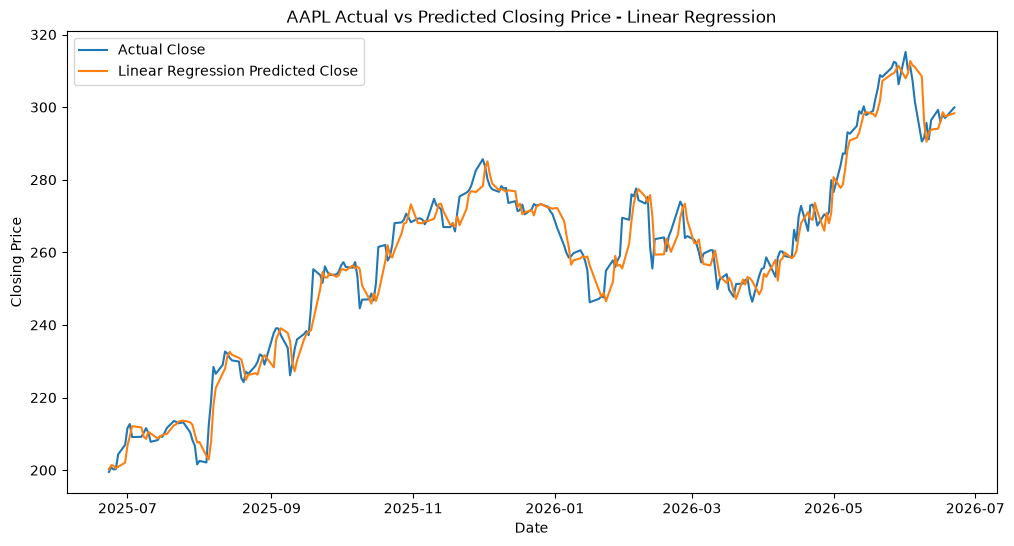

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(comparison_df.index, comparison_df["Actual_Close"], label="Actual Close")
plt.plot(comparison_df.index, comparison_df["Linear_Predicted_Close"], label="Linear Regression Predicted Close")

plt.title(f"{stock_symbol} Actual vs Predicted Closing Price - Linear Regression")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

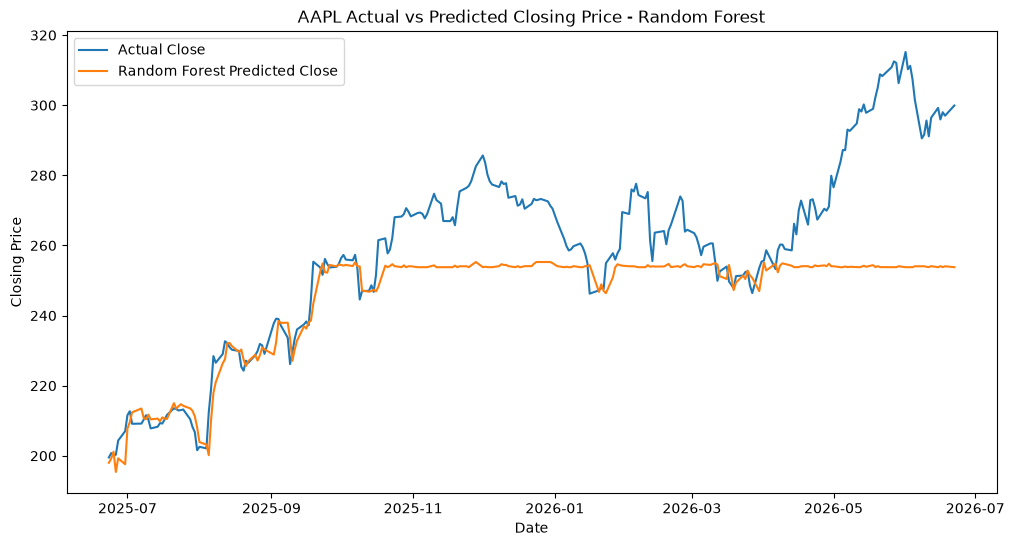

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(comparison_df.index, comparison_df["Actual_Close"], label="Actual Close")
plt.plot(comparison_df.index, comparison_df["RandomForest_Predicted_Close"], label="Random Forest Predicted Close")

plt.title(f"{stock_symbol} Actual vs Predicted Closing Price - Random Forest")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

## Step 11: Final Prediction

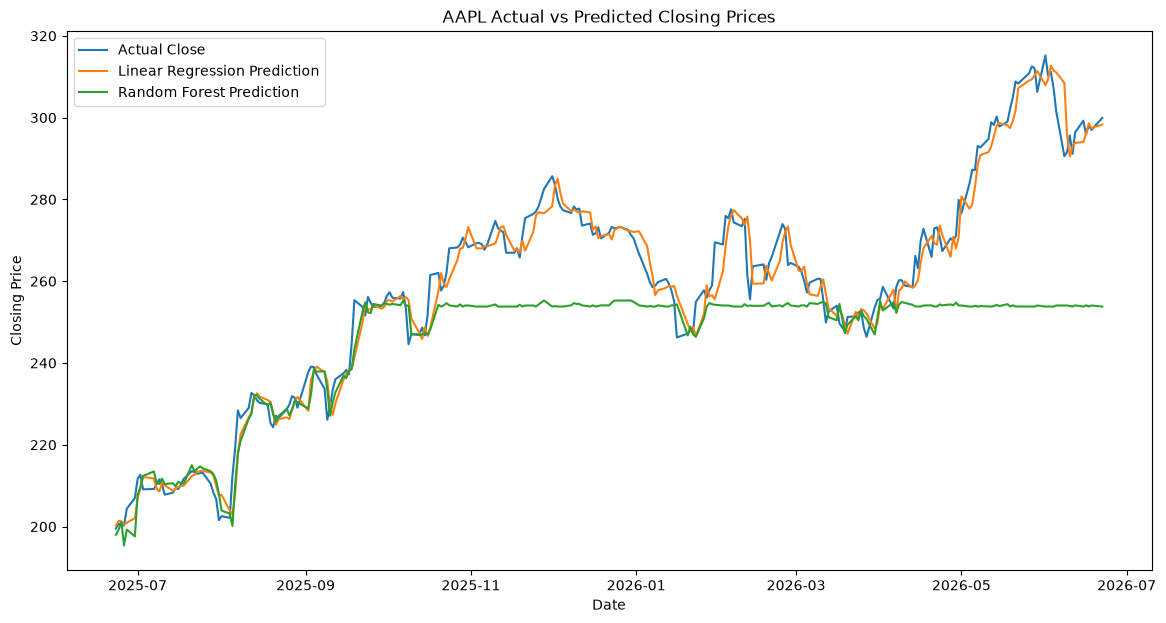

In [26]:
plt.figure(figsize=(14, 7))

plt.plot(comparison_df.index, comparison_df["Actual_Close"], label="Actual Close")
plt.plot(comparison_df.index, comparison_df["Linear_Predicted_Close"], label="Linear Regression Prediction")
plt.plot(comparison_df.index, comparison_df["RandomForest_Predicted_Close"], label="Random Forest Prediction")

plt.title(f"{stock_symbol} Actual vs Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [27]:
latest_data = data[features].iloc[-1:]

next_close_linear = linear_model.predict(latest_data)

next_close_rf = rf_model.predict(latest_data)

print(f"Predicted next closing price for {stock_symbol}:")
print("Linear Regression:", next_close_linear[0])
print("Random Forest:", next_close_rf[0])

Predicted next closing price for AAPL:
Linear Regression: 298.31387552294666
Random Forest: 253.79666336059572


In [28]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,High,0.441601
2,Low,0.357486
0,Open,0.198339
3,Volume,0.002574


In [29]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,High,0.441601
2,Low,0.357486
0,Open,0.198339
3,Volume,0.002574


## Step 12: Final Insights

- The dataset was downloaded from Yahoo Finance using the yfinance library.
- Apple stock data was used in this notebook.
- Features used for prediction were Open, High, Low, and Volume.
- The target variable was Next_Close, which represents the next day's closing price.
- Two regression models were trained: Linear Regression and Random Forest Regressor.
- The models were evaluated using MAE, RMSE, and R2 Score.
- Actual vs predicted closing prices were plotted for comparison.
- Random Forest can capture non-linear patterns, while Linear Regression gives a simple baseline.
- This project is for educational purposes only and should not be used as financial advice.